# Predicting NFL Game Totals with Betting Lines, Weather, and Stadium Context

## Introduction

This analysis is designed for a sports bettor or sports analyst who wants to better understand what drives total points scored in NFL games. In particular, this project asks whether betting market expectations, weather conditions, and game environment variables can help explain and predict final game totals.

The central modeling goal is to predict **total points scored** in an NFL game. To do this, we combine multiple datasets containing game results, stadium characteristics, weather conditions, and Vegas betting lines. The analysis begins with data quality checks and exploratory data analysis, then proceeds to feature engineering and regression modeling.

The practical motivation is straightforward: betting markets provide a strong baseline estimate of expected scoring, but weather and stadium context may shift actual totals away from that expectation. This project tests whether those additional variables improve our ability to explain and predict game scoring outcomes.

In [1]:
# Core data tools
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statsmodels for prettier regression output
import statsmodels.api as sm

# Utility
from math import sqrt
import warnings

# Suppress noisy warnings so notebook stays readable
warnings.simplefilter(action="ignore", category=FutureWarning)

## Load the cleaned datasets

The cleaned CSV files were prepared in a separate workflow so that this notebook can focus on analysis rather than raw-data cleaning. Each file has a specific purpose:

- `games.csv` contains game-level scoring and schedule structure
- `stadiums.csv` contains stadium and indoor/outdoor context
- `weather.csv` contains weather features aligned at the game level
- `betting_data.csv` contains Vegas line information
- `teams.csv` contains team lookup information

In [2]:
games = pd.read_csv("games.csv")
teams = pd.read_csv("teams.csv")
stadiums = pd.read_csv("stadiums.csv")
betting = pd.read_csv("betting_data.csv")
weather = pd.read_csv("weather.csv")

In [3]:
games.columns = games.columns.str.lower()
teams.columns = teams.columns.str.lower()
stadiums.columns = stadiums.columns.str.lower()
betting.columns = betting.columns.str.lower()
weather.columns = weather.columns.str.lower()

In [4]:
print("games shape:", games.shape)
print("teams shape:", teams.shape)
print("stadiums shape:", stadiums.shape)
print("betting shape:", betting.shape)
print("weather shape:", weather.shape)

games shape: (5430, 9)
teams shape: (37, 2)
stadiums shape: (5430, 5)
betting shape: (5430, 4)
weather shape: (5430, 7)


## Merge the datasets into a single analysis dataframe

Following the style used in class, I now merge the component datasets into one modeling dataframe. The key design choice is to use `game_id` wherever possible so that joins are stable and reproducible.

In [5]:
# Start with the core game-level table
analysis_df = games.merge(stadiums, on="game_id", how="left")

# Add weather data
analysis_df = analysis_df.merge(weather, on="game_id", how="left")

# Add betting data
analysis_df = analysis_df.merge(betting, on="game_id", how="left")

In [6]:
analysis_df.head()

,game_id,season,week,date,home_team,away_team,home_score,away_score,total_points,venue_name,...,is_indoor,avg_temp,rain_sum,wind_speed_avg,snowfall_sum,rain_any,snow_any,team_favorite_id,spread_favorite,vegas_total
0,1,2006,1.0,2006-09-08 00:30:00.000,Pittsburgh Steelers,Miami Dolphins,28,17,45,Acrisure Stadium,...,False,67.28,0.0,4.1,0.0,False,False,PIT,-1.5,34.5
1,2,2006,1.0,2006-09-10 17:00:00.000,Cleveland Browns,New Orleans Saints,14,19,33,Huntington Bank Field,...,False,65.84,0.1,16.2,0.0,True,False,CLE,-3.0,36.0
2,3,2006,1.0,2006-09-10 17:00:00.000,Detroit Lions,Seattle Seahawks,6,9,15,Ford Field,...,True,60.26,0.1,19.6,0.0,True,False,SEA,-6.0,44.0
3,4,2006,1.0,2006-09-10 17:00:00.000,Tennessee Titans,New York Jets,16,23,39,Nissan Stadium,...,False,76.46,0.5,5.9,0.0,True,False,TEN,-2.5,35.0
4,5,2006,1.0,2006-09-10 17:00:00.000,Kansas City Chiefs,Cincinnati Bengals,10,23,33,GEHA Field at Arrowhead Stadium,...,False,70.88,1.0,10.7,0.0,True,False,CIN,-1.5,49.5


## Validate the merged data

Before doing any EDA or modeling, I check whether the joins worked as intended. This includes confirming row counts, uniqueness of `game_id`, and missing values in the newly added fields.

In [7]:
print("analysis_df shape:", analysis_df.shape)
print("Unique game_id count:", analysis_df["game_id"].nunique())
print("Duplicate game_id rows:", analysis_df["game_id"].duplicated().sum())

analysis_df shape: (5430, 22)
Unique game_id count: 5430
Duplicate game_id rows: 0


In [8]:
analysis_df[
    [
        "venue_name",
        "is_indoor",
        "avg_temp",
        "wind_speed_avg",
        "rain_any",
        "snow_any",
        "vegas_total",
        "spread_favorite"
    ]
].isna().sum()

venue_name         0
is_indoor          0
avg_temp           0
wind_speed_avg     0
rain_any           0
snow_any           0
vegas_total        1
spread_favorite    1
dtype: int64

In [9]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5430 entries, 0 to 5429
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           5430 non-null   int64  
 1   season            5430 non-null   int64  
 2   week              5430 non-null   float64
 3   date              5430 non-null   object 
 4   home_team         5430 non-null   object 
 5   away_team         5430 non-null   object 
 6   home_score        5430 non-null   int64  
 7   away_score        5430 non-null   int64  
 8   total_points      5430 non-null   int64  
 9   venue_name        5430 non-null   object 
 10  venue_city        5430 non-null   object 
 11  venue_state       5402 non-null   object 
 12  is_indoor         5430 non-null   bool   
 13  avg_temp          5430 non-null   float64
 14  rain_sum          5430 non-null   float64
 15  wind_speed_avg    5430 non-null   float64
 16  snowfall_sum      5430 non-null   float64


## Add readable team names

The game-level table already contains team names in some versions of the dataset, but I explicitly merge team lookup information here so the workflow clearly shows how multiple datasets are combined.

In [10]:
home_teams = teams[["team_id", "team_name"]].rename(
    columns={"team_id": "home_team", "team_name": "home_team_name"}
)

away_teams = teams[["team_id", "team_name"]].rename(
    columns={"team_id": "away_team", "team_name": "away_team_name"}
)

In [11]:
analysis_df = analysis_df.merge(home_teams, on="home_team", how="left")
analysis_df = analysis_df.merge(away_teams, on="away_team", how="left")

In [12]:
analysis_df[
    [
        "game_id",
        "season",
        "week",
        "date",
        "home_team",
        "home_team_name",
        "away_team",
        "away_team_name",
        "total_points",
        "vegas_total"
    ]
].head()

,game_id,season,week,date,home_team,home_team_name,away_team,away_team_name,total_points,vegas_total
0,1,2006,1.0,2006-09-08 00:30:00.000,Pittsburgh Steelers,Pittsburgh Steelers,Miami Dolphins,Miami Dolphins,45,34.5
1,2,2006,1.0,2006-09-10 17:00:00.000,Cleveland Browns,Cleveland Browns,New Orleans Saints,New Orleans Saints,33,36.0
2,3,2006,1.0,2006-09-10 17:00:00.000,Detroit Lions,Detroit Lions,Seattle Seahawks,Seattle Seahawks,15,44.0
3,4,2006,1.0,2006-09-10 17:00:00.000,Tennessee Titans,Tennessee Titans,New York Jets,New York Jets,39,35.0
4,5,2006,1.0,2006-09-10 17:00:00.000,Kansas City Chiefs,Kansas City Chiefs,Cincinnati Bengals,Cincinnati Bengals,33,49.5


## Exploratory Data Analysis (EDA)

Before building predictive models, I begin by exploring patterns in the data to understand how scoring varies across different game environments.

In particular, I focus on three questions:

1. Do indoor stadiums produce higher scoring games than outdoor stadiums?
2. How does weather (temperature, wind, precipitation) relate to total scoring?
3. How closely do Vegas betting lines track actual game outcomes?

Because indoor stadiums eliminate exposure to weather conditions, analyses that examine weather effects focus only on **outdoor games**. This ensures that the relationships observed between weather variables and scoring reflect environments where weather can realistically influence gameplay.

These exploratory summaries provide intuition about which variables are likely to be useful predictors in the modeling stage.

### Indoor vs Outdoor Scoring

This table compares scoring distributions between indoor and outdoor stadiums. Indoor stadiums eliminate wind, precipitation, and extreme temperatures, which may allow offenses to perform more consistently.

The mean and median scoring values help determine whether indoor games tend to produce higher total points.

In [13]:
indoor_scoring = (
    analysis_df
    .groupby("is_indoor")["total_points"]
    .agg(["count", "mean", "median", "std"])
    .rename(index={False: "Outdoor", True: "Indoor"})
)

indoor_scoring

,count,mean,median,std
is_indoor,,,,
Outdoor,3915,44.208685,44.0,13.849624
Indoor,1515,47.285809,47.0,14.092618


**Interpretation**

Indoor games average approximately **47.3 total points**, compared with **44.2 points in outdoor games**. This suggests that controlled stadium environments may contribute to slightly higher scoring outcomes.

### Rain vs Dry Conditions

Rain can reduce passing efficiency, increase turnovers, and make kicking more difficult. To evaluate this effect, I compare total points scored in games played with rain versus games played in dry conditions.

In [14]:
rain_scoring = (
    analysis_df[analysis_df["is_indoor"] == False]
    .groupby("rain_any")["total_points"]
    .agg(["count", "mean", "median", "std"])
    .rename(index={False: "No Rain", True: "Rain"})
)

rain_scoring

,count,mean,median,std
rain_any,,,,
No Rain,2335,44.726767,44.0,13.850309
Rain,1580,43.443038,43.0,13.817454


### Interpretation

Games played without rain average approximately **44.7 total points**, while games played in rain average about **43.4 points**.

The roughly one-point difference suggests that rain may slightly suppress scoring, but the effect appears relatively modest. While rain can affect ball handling and passing efficiency, NFL offenses may be able to adjust their play style to compensate for these conditions.

### Snow Games

Snow games are often assumed to slow offenses due to reduced footing, ball handling challenges, and difficult kicking conditions. To evaluate whether snowfall meaningfully affects scoring, I compare total points in games with snowfall versus games without snow.

In [15]:
snow_scoring = (
    analysis_df[analysis_df["is_indoor"] == False]
    .groupby("snow_any")["total_points"]
    .agg(["count", "mean", "median", "std"])
    .rename(index={False: "No Snow", True: "Snow"})
)

snow_scoring

,count,mean,median,std
snow_any,,,,
No Snow,3625,44.154483,44.0,13.716515
Snow,290,44.886207,44.0,15.426940


### Interpretation

Snow games average approximately **44.9 total points**, compared with about **44.2 points** in games without snow.

This suggests that snowfall alone does not meaningfully reduce scoring in this dataset. However, the number of snow games is relatively small compared with dry games, which may limit the strength of this conclusion.

### Scoring by Temperature Range

Temperature may influence game pace and player performance. Extremely cold conditions could reduce offensive efficiency, while moderate temperatures might allow offenses to operate more effectively. To explore this relationship, games are grouped into temperature ranges and average scoring is calculated for each group.

In [16]:
analysis_df.loc[analysis_df["is_indoor"] == False, "temp_bucket"] = pd.cut(
    analysis_df.loc[analysis_df["is_indoor"] == False, "avg_temp"],
    bins=[-20, 32, 50, 70, 90, 120],
    labels=["Freezing (<32F)", "Cold (32-50F)", "Cool (50-70F)", "Warm (70-90F)", "Hot (90F+)"]
)

In [17]:
temp_scoring = (
    analysis_df[analysis_df["is_indoor"] == False]
    .groupby("temp_bucket")["total_points"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)

temp_scoring

,count,mean,median,std
temp_bucket,,,,
Freezing (<32F),400,45.000000,44.0,14.456226
Cold (32-50F),1223,43.524939,43.0,14.200084
Cool (50-70F),1715,44.607580,44.0,13.587413
Warm (70-90F),577,43.923744,44.0,13.397284
Hot (90F+),0,NaN,NaN,NaN


### Interpretation

Scoring appears relatively stable across temperature ranges, with average totals generally falling between **43 and 45 points**.

This suggests that temperature alone may not strongly influence scoring outcomes in NFL games. While extreme cold might be expected to slow offenses, the data indicates that temperature likely plays a smaller role than other environmental factors such as wind.

### High Wind Conditions

Wind can affect passing accuracy, long field goal attempts, and deep passing plays. To examine this relationship, I compare scoring in games with wind speeds above 15 mph to games with lower wind speeds.

In [18]:
analysis_df.loc[analysis_df["is_indoor"] == False, "high_wind"] = (
    analysis_df.loc[analysis_df["is_indoor"] == False, "wind_speed_avg"] >= 15
)

In [19]:
wind_scoring = (
    analysis_df[analysis_df["is_indoor"] == False]
    .groupby("high_wind")["total_points"]
    .agg(["count", "mean", "median", "std"])
    .rename(index={False: "Normal Wind", True: "High Wind (15+ mph)"})
)

wind_scoring

,count,mean,median,std
high_wind,,,,
Normal Wind,3065,44.919413,44.0,13.758419
High Wind (15+ mph),850,41.645882,41.0,13.882581


### Interpretation

Wind appears to have a more noticeable impact on scoring than other weather variables. Games with normal wind conditions average about **44.9 points**, while games with wind speeds above **15 mph** average roughly **41.6 points**.

This difference of more than **three points** suggests that strong wind may meaningfully suppress offensive production by affecting passing accuracy and long field goal attempts.

### EDA Summary

The exploratory analysis suggests that **Vegas betting lines are likely the strongest predictor of game totals**, as betting markets incorporate many sources of information about teams and expected scoring.

Weather variables appear to have more modest effects overall, though **wind conditions show a clearer relationship with scoring outcomes**, particularly in outdoor stadiums. These observations guide the modeling approach in the next section, where regression models will be used to quantify how well these variables predict total points scored.

## Visual Exploratory Analysis

While summary tables provide useful numerical comparisons, visualizations help reveal relationships and patterns that may not be immediately obvious from aggregated statistics.

The following charts explore how total points scored in NFL games relate to betting market expectations, stadium environment, and weather conditions. These visualizations complement the earlier tables and provide additional intuition for which variables may be useful predictors in the modeling stage.

### Vegas Line vs Actual Scoring

This scatter plot compares the Vegas betting line for total points with the actual total points scored in each game.

Betting markets incorporate information about team strength, injuries, pace of play, and historical scoring patterns. If these markets are effective at forecasting game outcomes, we would expect to observe a strong positive relationship between the Vegas total and the actual points scored.

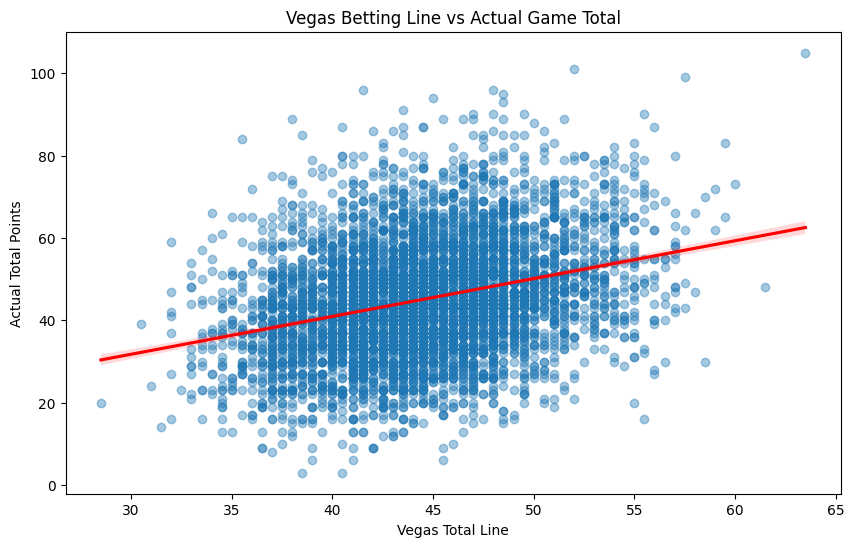

In [20]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=analysis_df,
    x="vegas_total",
    y="total_points",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.xlabel("Vegas Total Line")
plt.ylabel("Actual Total Points")
plt.title("Vegas Betting Line vs Actual Game Total")

plt.show()

### Interpretation

The scatter plot shows a clear positive relationship between the Vegas betting line and the actual total points scored. Games with higher Vegas totals tend to produce higher scoring outcomes, while games with lower Vegas totals tend to produce fewer points.

Although there is still substantial variation around the betting line, the overall upward trend suggests that betting markets provide a strong baseline estimate of expected scoring. This makes the Vegas total a natural candidate for the primary predictor in the regression model.

### Distribution of NFL Game Totals

This histogram shows the overall distribution of total points scored in NFL games across the dataset.

Understanding the baseline scoring distribution provides useful context for later modeling and helps identify whether extremely high or low scoring games occur frequently.

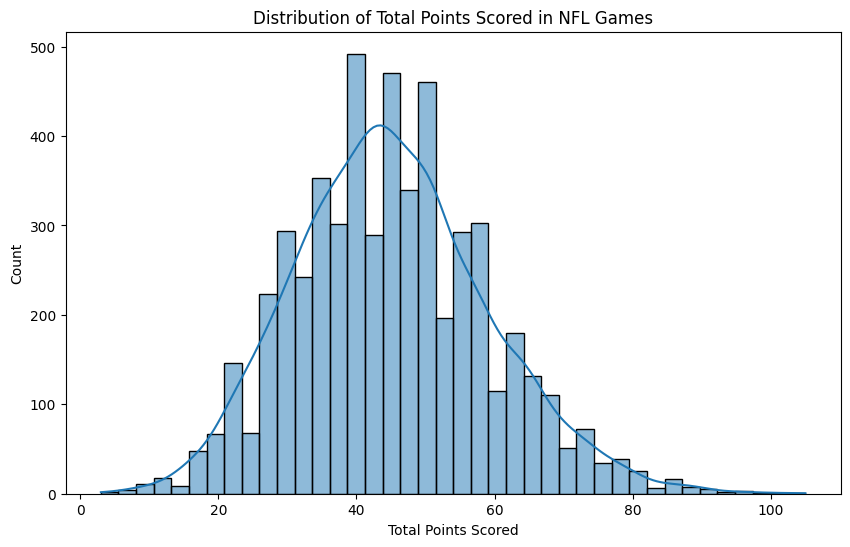

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    analysis_df["total_points"],
    bins=40,
    kde=True
)

plt.xlabel("Total Points Scored")
plt.title("Distribution of Total Points Scored in NFL Games")

plt.show()

### Interpretation

The distribution of total points appears roughly bell-shaped and centered around the mid-40s. Most games fall between approximately 30 and 60 total points, with extremely high-scoring or low-scoring games occurring relatively infrequently.

This pattern suggests that while scoring outcomes can vary substantially from game to game, there is still a clear central tendency in NFL scoring. Predictive models should therefore be able to capture a meaningful portion of this variation.

### Indoor vs Outdoor Scoring Distribution

This boxplot compares the distribution of total points scored in indoor versus outdoor stadiums.

Indoor stadiums remove environmental variability such as wind, precipitation, and temperature extremes. As a result, offenses may be able to operate more consistently in indoor environments.

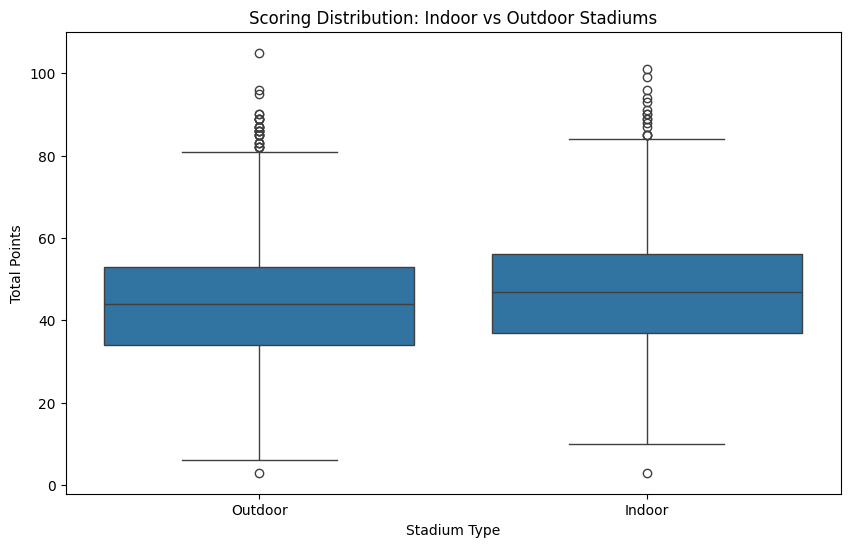

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=analysis_df,
    x="is_indoor",
    y="total_points"
)

plt.xticks([0,1], ["Outdoor", "Indoor"])

plt.xlabel("Stadium Type")
plt.ylabel("Total Points")
plt.title("Scoring Distribution: Indoor vs Outdoor Stadiums")

plt.show()

### Interpretation

The boxplot shows that indoor games tend to have slightly higher median scoring and a somewhat tighter distribution compared with outdoor games. This pattern aligns with the earlier summary table, which showed higher average scoring in indoor environments.

While the difference is not extremely large, it suggests that stadium environment may play a role in shaping offensive performance and scoring outcomes.

### Wind Speed and Game Scoring

Wind can affect passing accuracy, deep passing plays, and long field goal attempts. These factors may reduce offensive efficiency in games with strong wind conditions.

This scatter plot examines whether higher wind speeds are associated with lower total scoring in NFL games.

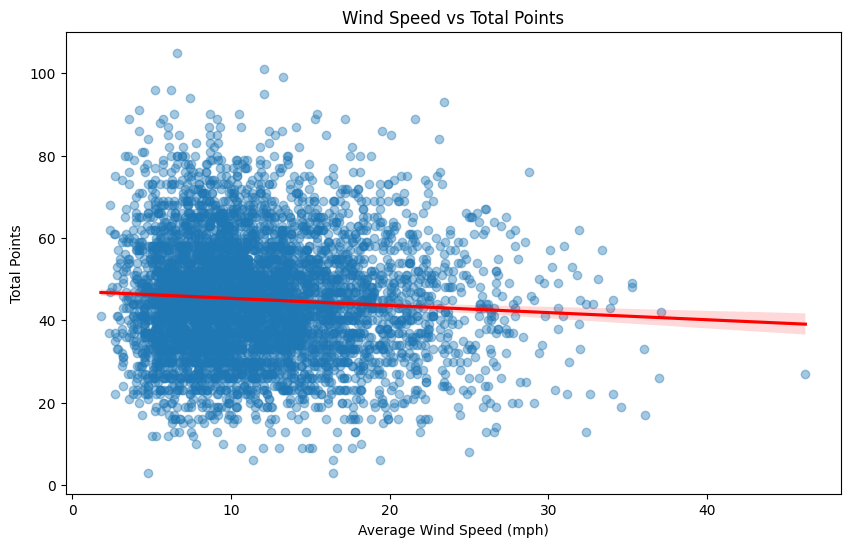

In [23]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=analysis_df,
    x="wind_speed_avg",
    y="total_points",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.xlabel("Average Wind Speed (mph)")
plt.ylabel("Total Points")
plt.title("Wind Speed vs Total Points")

plt.show()

### Interpretation

The scatter plot suggests a modest negative relationship between wind speed and total scoring. Games played in higher wind conditions appear more likely to produce lower scoring outcomes.

Although the relationship is not perfectly linear, the downward trend supports the earlier table analysis showing that games with wind speeds above 15 mph tend to produce fewer points. This indicates that wind may be one of the more meaningful weather variables affecting scoring.

## Transition to Modeling

The exploratory analysis highlights several patterns that inform the modeling approach.

First, the Vegas betting line shows a strong relationship with actual scoring outcomes, suggesting that it will likely serve as the most powerful predictor in the model. Second, certain environmental factors — particularly wind — appear to influence scoring in outdoor games. Finally, stadium environment may also play a role, as indoor games tend to produce slightly higher totals.

The next section builds regression models to quantify these relationships and evaluate how well betting market expectations and environmental variables can predict total points scored in NFL games.

## Feature Engineering and Model Setup

After completing the exploratory analysis, the next step is to construct predictive models for total points scored in NFL games.

The primary modeling goal is to predict the variable **total_points**, which represents the combined score of both teams in a game.

The exploratory analysis suggested that the **Vegas betting line** is likely the strongest predictor of total scoring, since betting markets incorporate information about team strength, pace of play, injuries, and other contextual factors. Weather conditions and stadium environment may also influence scoring outcomes.

To evaluate these relationships, I construct regression models using the following features:

• Vegas total line (primary predictor)  
• Stadium environment (indoor vs outdoor)  
• Weather variables (temperature, wind, rain, snow)  
• Spread of the betting favorite

These variables are assembled into a modeling dataset that will be used for training and evaluating the regression models.

In [24]:
# Define target variable
y = analysis_df["total_points"]

# Define model features
X = analysis_df[
    [
        "vegas_total",
        "wind_speed_avg",
        "avg_temp",
        "rain_any",
        "snow_any",
        "is_indoor",
        "spread_favorite"
    ]
]

# Quick preview
X.head()

,vegas_total,wind_speed_avg,avg_temp,rain_any,snow_any,is_indoor,spread_favorite
0,34.5,4.1,67.28,False,False,False,-1.5
1,36.0,16.2,65.84,True,False,False,-3.0
2,44.0,19.6,60.26,True,False,True,-6.0
3,35.0,5.9,76.46,True,False,False,-2.5
4,49.5,10.7,70.88,True,False,False,-1.5


In [26]:
# Convert boolean columns to integers
X.loc[:, "rain_any"] = X["rain_any"].astype(int)
X.loc[:, "snow_any"] = X["snow_any"].astype(int)
X.loc[:, "is_indoor"] = X["is_indoor"].astype(int)

X.head()

,vegas_total,wind_speed_avg,avg_temp,rain_any,snow_any,is_indoor,spread_favorite
0,34.5,4.1,67.28,0,0,0,-1.5
1,36.0,16.2,65.84,1,0,0,-3.0
2,44.0,19.6,60.26,1,0,1,-6.0
3,35.0,5.9,76.46,1,0,0,-2.5
4,49.5,10.7,70.88,1,0,0,-1.5


In [34]:
# Remove row with missing values
model_df = pd.concat([X, y], axis=1).dropna()

# Separate features and target again
X = model_df.drop(columns=["total_points"])
y = model_df["total_points"]

print("Final modeling dataset shape:", X.shape)

Final modeling dataset shape: (5429, 7)


### Train/Test Split

To evaluate model performance, the dataset is split into a training set and a testing set.

The model is trained on 80% of the data and evaluated on the remaining 20%. This allows us to measure how well the model generalizes to unseen games.

In [38]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=38
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 4343
Testing rows: 1086


### Baseline Model: Vegas Total Only

Because the exploratory analysis showed a strong relationship between the Vegas total and actual scoring, the first model uses only the Vegas betting line as a predictor.

This provides a useful baseline to evaluate whether adding weather and stadium variables improves predictive performance.

In [39]:
# Baseline model using Vegas line only

X_train_baseline = X_train[["vegas_total"]]
X_test_baseline = X_test[["vegas_total"]]

baseline_model = LinearRegression()

baseline_model.fit(X_train_baseline, y_train)

baseline_predictions = baseline_model.predict(X_test_baseline)

In [40]:
# Baseline model performance

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline Model Performance (Vegas Total Only)")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²:", round(baseline_r2, 3))

Baseline Model Performance (Vegas Total Only)
MAE: 10.46
RMSE: 13.27
R²: 0.099


### Interpretation

The baseline model uses only the Vegas total as a predictor of final game scoring.

The model produces a mean absolute error of approximately 10.5 points and an R² of about 0.10. This indicates that the Vegas betting line captures some information about expected scoring, but it explains only a modest portion of the variation in actual game totals.

This result is not surprising. While betting markets incorporate a wide range of information about team strength, pace of play, and historical scoring trends, many factors that influence game outcomes remain unpredictable.

The relatively low explanatory power of the baseline model suggests that additional variables such as weather conditions and stadium environment may help improve predictive performance. The next model incorporates these additional features to test whether they provide meaningful improvements.

## Full Regression Model

The baseline model used only the Vegas betting line as a predictor of game totals. While this provided a useful benchmark, the exploratory analysis suggested that environmental factors such as weather and stadium conditions may also influence scoring outcomes.

To evaluate whether these variables improve predictive performance, I construct a second regression model that includes additional predictors:

• Vegas total line  
• Wind speed  
• Temperature  
• Rain indicator  
• Snow indicator  
• Indoor stadium indicator  
• Spread of the betting favorite  

This model allows us to test whether incorporating environmental context improves our ability to predict total points scored in NFL games.

In [41]:
# Full regression model using all features

full_model = LinearRegression()

full_model.fit(X_train, y_train)

full_predictions = full_model.predict(X_test)

In [42]:
# Full model performance

full_mae = mean_absolute_error(y_test, full_predictions)
full_rmse = sqrt(mean_squared_error(y_test, full_predictions))
full_r2 = r2_score(y_test, full_predictions)

print("Full Model Performance (Vegas + Weather + Stadium)")
print("MAE:", round(full_mae, 2))
print("RMSE:", round(full_rmse, 2))
print("R²:", round(full_r2, 3))

Full Model Performance (Vegas + Weather + Stadium)
MAE: 10.44
RMSE: 13.23
R²: 0.104


In [43]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Baseline (Vegas Only)", "Full Model (Vegas + Weather + Stadium)"],
    "MAE": [baseline_mae, full_mae],
    "RMSE": [baseline_rmse, full_rmse],
    "R2": [baseline_r2, full_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline (Vegas Only),10.461511,13.266688,0.099372
1,Full Model (Vegas + Weather + Stadium),10.440078,13.231858,0.104094


### Interpretation

The full regression model improves only modestly upon the baseline model. Mean absolute error falls slightly from **10.46** to **10.44**, RMSE declines from **13.27** to **13.23**, and R² increases from **0.099** to **0.104**.

This suggests that weather and stadium variables do contain useful information, but their incremental predictive value is relatively limited once the Vegas total is already included. In other words, the betting market appears to capture much of the information that is most relevant for predicting final scoring outcomes.

This result is consistent with the earlier exploratory analysis. Wind and indoor stadium status showed some relationship with scoring, but temperature, rain, and snow appeared to have weaker effects. As a result, adding environmental variables improves the model slightly, but not dramatically.

In [44]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": full_model.coef_
})

coefficients.sort_values(by="Coefficient", key=abs, ascending=False)

,Feature,Coefficient
4,snow_any,1.787087
5,is_indoor,1.607064
0,vegas_total,0.879691
1,wind_speed_avg,-0.141356
3,rain_any,-0.067856
6,spread_favorite,-0.048594
2,avg_temp,0.001837


### Interpreting Model Coefficients

The coefficient table helps identify which predictors contribute most strongly to the model.

The **Vegas total** remains the most practically important predictor, with a large positive coefficient, confirming that betting market expectations are strongly associated with final scoring outcomes. The **indoor stadium indicator** is also positive, which aligns with the earlier finding that indoor games tend to score slightly more points. **Wind speed** has a negative coefficient, supporting the exploratory finding that stronger wind conditions are associated with lower scoring.

Rain and temperature appear to contribute relatively little to the model, while the positive coefficient on snow should be interpreted cautiously because snow games are relatively rare in the dataset.

## Predicted vs Actual Game Totals

To further evaluate model performance, we compare the model’s predicted totals with the actual totals observed in the test set.

If the model fits well, points should cluster around the 45-degree line where predicted values equal actual values. Larger deviations from that line indicate prediction error.

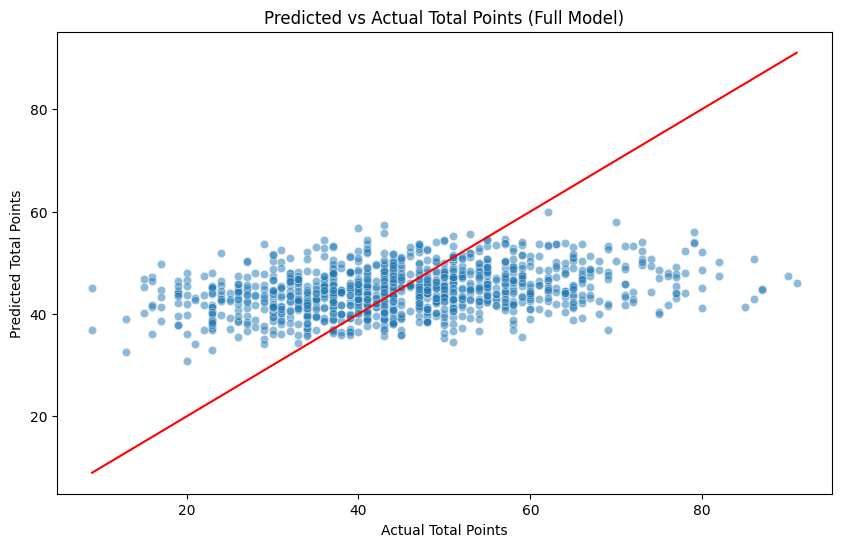

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=full_predictions,
    alpha=0.5
)

# 45-degree reference line
min_val = min(y_test.min(), full_predictions.min())
max_val = max(y_test.max(), full_predictions.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("Actual Total Points")
plt.ylabel("Predicted Total Points")
plt.title("Predicted vs Actual Total Points (Full Model)")

plt.show()

### Interpretation

The predicted-versus-actual chart shows that the model captures the broad direction of scoring outcomes, but substantial variation remains around the 45-degree line.

This pattern reinforces the earlier performance metrics: the model has some predictive value, but NFL scoring remains difficult to forecast precisely. Much of the remaining error likely reflects unpredictable game-specific factors such as turnovers, injuries, and late-game variance.

## Residual Analysis

Residuals are defined as the difference between actual totals and predicted totals. Examining residuals helps assess whether the model’s errors are centered around zero and whether any strong patterns remain unexplained.

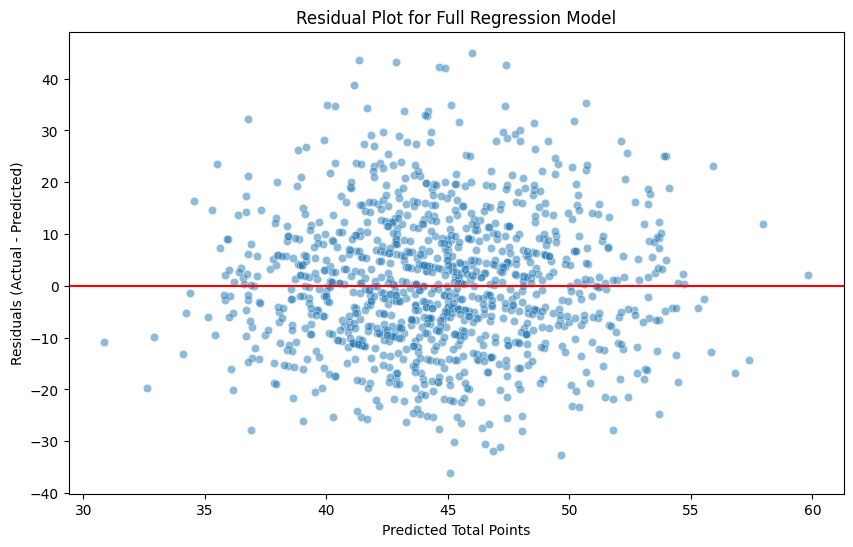

In [46]:
residuals = y_test - full_predictions

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=full_predictions,
    y=residuals,
    alpha=0.5
)

plt.axhline(0, color="red")

plt.xlabel("Predicted Total Points")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Full Regression Model")

plt.show()

### Interpretation

The residual plot shows that prediction errors are centered roughly around zero, which suggests that the model is not systematically overpredicting or underpredicting game totals across most of the prediction range.

At the same time, the spread of residuals remains fairly wide, which reflects the inherent unpredictability of NFL scoring. This is consistent with the relatively modest R² values observed in both the baseline and full regression models.

## Example: Predicting a Future Game Total

To illustrate how the model can be used in practice, I create a hypothetical future game scenario and generate a predicted total.

This example is not intended to recommend a specific bet. Rather, it demonstrates how the fitted regression model can translate betting market expectations and environmental conditions into a projected scoring outcome.

In [47]:
future_game = pd.DataFrame({
    "vegas_total": [46.5],
    "wind_speed_avg": [12.0],
    "avg_temp": [48.0],
    "rain_any": [0],
    "snow_any": [0],
    "is_indoor": [0],
    "spread_favorite": [-3.5]
})

future_prediction = full_model.predict(future_game)[0]

print("Predicted total points:", round(future_prediction, 2))

Predicted total points: 46.04


### Interpretation

For this hypothetical game, the model predicts a total of approximately **46 points**.

This prediction is close to the Vegas baseline, which is expected given that the Vegas total is the strongest predictor in the model. Weather and stadium variables shift the estimate only modestly, which is consistent with the earlier finding that environmental factors add limited but measurable explanatory power.

## Practical Takeaways

Several practical insights emerge from this analysis.

First, the **Vegas total line** is by far the strongest baseline predictor of final scoring. This suggests that betting markets incorporate substantial information efficiently.

Second, **weather variables have limited incremental predictive value overall**, though **wind** appears to be the most meaningful environmental factor. Indoor stadiums also appear to support slightly higher scoring.

Third, while adding weather and stadium context improves model performance slightly, the gain is relatively modest. This implies that bettors or analysts should treat weather as a secondary adjustment rather than as the primary driver of expected scoring.

## Conclusion

This project examined whether NFL game totals can be predicted using betting lines, weather variables, and stadium context.

The results show that the **Vegas betting line** provides the strongest predictive signal, while environmental variables such as **wind** and **indoor stadium status** contribute only modest additional explanatory power. A baseline model using only the Vegas total produced reasonable results, and the full model improved performance slightly, though not dramatically.

These findings suggest that betting markets already capture much of the information relevant to expected scoring. Weather and stadium context can still matter, but their effects are generally smaller and more situational.

Overall, this analysis demonstrates that combining market expectations with contextual game information can produce a useful predictive framework, while also highlighting the limits of forecasting in a high-variance environment like NFL scoring.

Future work could extend this model by incorporating stronger team-level variables such as offensive efficiency, defensive efficiency, quarterback status, injuries, and recent team form.